Voy a hacer un cálculo teórico del ancho de la zona de carga espacial y la barrera de potencial para el AsGa y luego hago simulaciones en nanohub

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
k = 1.38e-23  # Boltzmann constant in J/K
T = 300  # Temperature in K
q = 1.6e-19  # Elementary charge in C

Nasga = 4.42e22  # atomic density of GaAs in atoms/cm^3
ni = 1.79e6  # intrinsic carrier concentration of GaAs in cm^-3
epsilonr = 12.9  # relative permittivity of GaAs
epsilon0 = 8.85e-14  # vacuum permittivity in F/cm

limit = 100000.0 # limit for the doping density in cm^-3

Na = Nasga / limit
Nd = Nasga / limit


$$
V_b = \frac{kT}{q}\ln\left(\frac{N_A N_D}{n_i^2}\right)
$$


$$W = \sqrt{\frac{2\varepsilon}{q}\left(\frac{1}{N_A}+\frac{1}{N_D}\right)V_b}$$

In [14]:
Vb = (k * T / q) * np.log((Na * Nd) / (ni ** 2))
W = np.sqrt((2 * epsilonr * epsilon0 / q) * (1 / Na + 1 / Nd) * Vb) * 1e7  # Convert from cm to nm
print(f"Built-in potential (Vb): {Vb:.2f} V")
print(f"Depletion width (W): {W:.2f} nm")

Built-in potential (Vb): 1.36 V
Depletion width (W): 93.63 nm


$$x_p = \sqrt{\frac{2\varepsilon}{q}\frac{N_D}{N_A(N_A+N_D)}V_b}$$

$$x_n = \sqrt{\frac{2\varepsilon}{q}\frac{N_A}{N_D(N_A+N_D)}V_b}$$

In [15]:
xp = np.sqrt(2 * epsilonr * epsilon0 * Vb * Nd / (q * Na * (Na + Nd))) * 1e4  # Convert from cm to nm
xn = np.sqrt(2 * epsilonr * epsilon0 * Vb * Na / (q * Nd * (Na + Nd))) * 1e4  # Convert from cm to nm
print(f"Depletion width on p-side (xp): {xp:.4f} μm")
print(f"Depletion width on n-side (xn): {xn:.4f} μm")

Depletion width on p-side (xp): 0.0468 μm
Depletion width on n-side (xn): 0.0468 μm


Ahora metemos estas condiciones en el simulador y vemos si se cumple

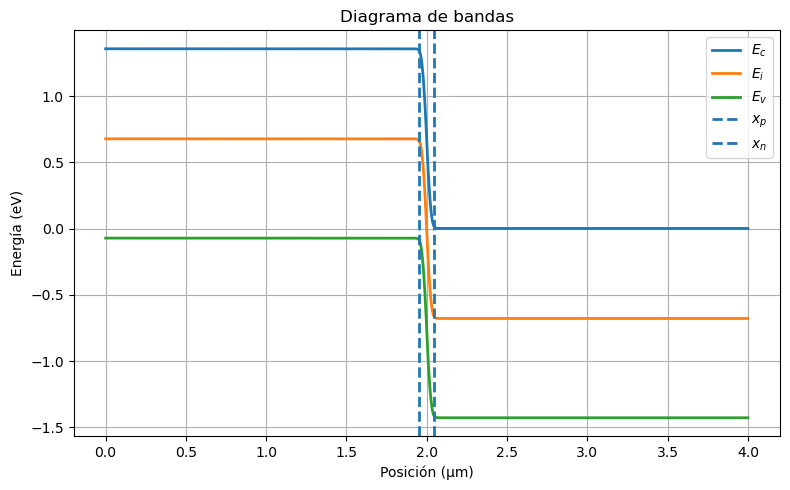

In [19]:

# =========================
# LEER ARCHIVOS
# =========================

# Los archivos tienen cabecera:
# Position (um), Energy (eV)

Ec = np.loadtxt("Ec.txt", delimiter=",", skiprows=1)
Ei = np.loadtxt("Ei.txt", delimiter=",", skiprows=1)
Ev = np.loadtxt("Ev.txt", delimiter=",", skiprows=1)

# =========================
# SEPARAR COLUMNAS
# =========================

x_Ec = Ec[:, 0]   # posición en micras
y_Ec = Ec[:, 1]   # energía en eV

x_Ei = Ei[:, 0]
y_Ei = Ei[:, 1]

x_Ev = Ev[:, 0]
y_Ev = Ev[:, 1]

# =========================
# LÍNEAS VERTICALES
# =========================
# Cambia estos valores cuando tengas xp y xn



# =========================
# PLOT
# =========================

plt.figure(figsize=(8, 5))

plt.plot(x_Ec, y_Ec, label=r"$E_c$", linewidth=2)
plt.plot(x_Ei, y_Ei, label=r"$E_i$", linewidth=2)
plt.plot(x_Ev, y_Ev, label=r"$E_v$", linewidth=2)

# Líneas verticales
plt.axvline(x=-xp +2, linestyle="--", linewidth=2, label=r"$x_p$")
plt.axvline(x=xn +2, linestyle="--", linewidth=2, label=r"$x_n$")

plt.xlabel("Posición (µm)")
plt.ylabel("Energía (eV)")
plt.title("Diagrama de bandas")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

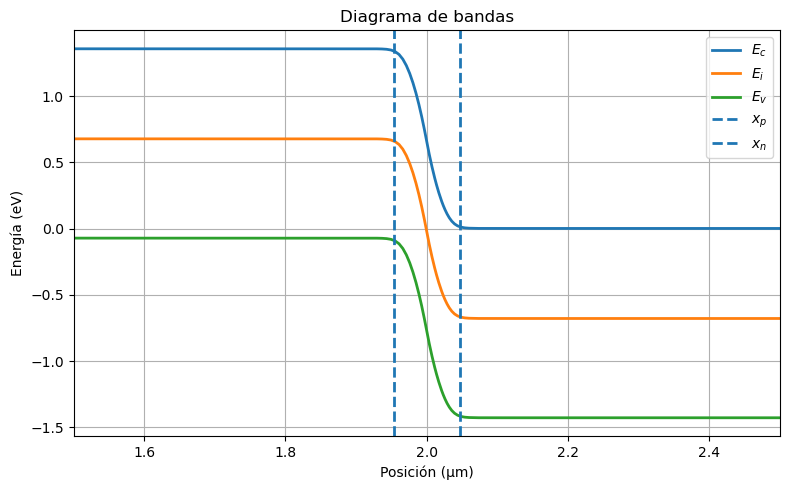

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(x_Ec, y_Ec, label=r"$E_c$", linewidth=2)
plt.plot(x_Ei, y_Ei, label=r"$E_i$", linewidth=2)
plt.plot(x_Ev, y_Ev, label=r"$E_v$", linewidth=2)

plt.axvline(x=-xp +2, linestyle="--", linewidth=2, label=r"$x_p$")
plt.axvline(x=xn + 2, linestyle="--", linewidth=2, label=r"$x_n$")

plt.xlim(1.5, 2.5)

plt.xlabel("Posición (µm)")
plt.ylabel("Energía (eV)")
plt.title("Diagrama de bandas")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

si este es el máximo vamos apañaos si los gnomos son nanométricos...